In [ ]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}

# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/figure_outputs_PSI"
# Create the output directory if it doesn't exist.
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath, recursive = TRUE)
}
# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_major_events.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index, -mode) %>%
  mutate(PSI = included_count/(included_count + skipped_count))
# Filter out the sequences that are in the blacklist.
blacklist_sequences <- read.csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(index_offset %in% blacklist_sequences$index_offset))


dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

psi_table_pivot_sample <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Convert to matrix.
psi_table_mat <- as.matrix(psi_table_pivot_sample %>% select(-index_offset))
rownames(psi_table_mat) <- psi_table_pivot_sample$index_offset

# Calculate upsilon for each row. 
upsilon_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon")

# Calculate reverse upsilon which is 1-values. 
psi_table_pivot_reverse <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  mutate_all(~ 1 - .)  

# Calculate upsilon for each row.
upsilon_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon_reverse")


# Calculate tau for each row.
tau_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau")

# Calculate reverse tau which is 1-values.
tau_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau_reverse")

# Get num NA per row. 
num_na_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) sum(is.na(x))) %>% 
  as.data.frame() %>% 
  setNames("num_na")

# Get min of each row.
min_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) min(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("min")

# Get max of each row.
max_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) max(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("max")
# Get mean of each row.
mean_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) mean(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("mean")

# Get median of each row.
median_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) median(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("median")

# Get the sample where the PSI is max.
max_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.max(x))) %>% 
  as.data.frame() %>% 
  setNames("max_sample")

# Get the sample where the PSI is min.
min_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.min(x))) %>% 
  as.data.frame() %>% 
  setNames("min_sample")

cell_specific_score <- data.frame(index_offset = psi_table_pivot$index_offset, 
                                  upsilon = upsilon_values$upsilon, 
                                  upsilon_reverse = upsilon_values_reverse$upsilon_reverse,
                                  tau = tau_values$tau,
                                  tau_reverse = tau_values_reverse$tau_reverse,
                                  num_na_per_row = num_na_per_row$num_na,
                                  row_max = max_per_row$max,
                                  row_min = min_per_row$min,
                                  row_mean = mean_per_row$mean,
                                  row_median = median_per_row$median,
                                  max_sample = max_sample_per_row$max_sample,
                                  min_sample = min_sample_per_row$min_sample) %>%
  filter(num_na_per_row < 10)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

# First plot some replicate correlations. 

Warning message:
“Removed 1283 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1186 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 530 rows containing missing values or values outside the scale range
(`geom_point()`).”


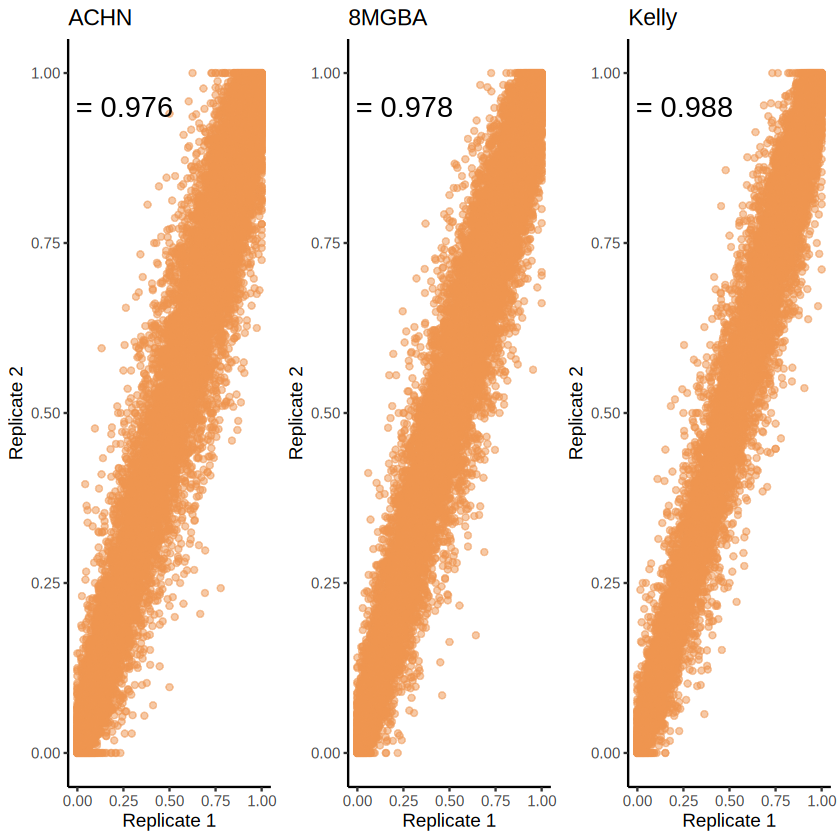

In [7]:
library(ggpointdensity)
library(ggrastr)
target_cell_type <- "ACHN"
target_cell_type_data <- final_psi_table_filtered %>% 
  filter(condition == target_cell_type) %>% 
  dplyr::select(sample, index_offset, PSI) %>% 
  pivot_wider(names_from = c(sample), values_from = PSI)

# Calculate Pearson correlation
pearson_r <- cor(target_cell_type_data$`ACHN-rep1`, target_cell_type_data$`ACHN-rep2`, use = "complete.obs")
r_squared <- pearson_r^2

p1 <- ggplot(target_cell_type_data, aes(x = `ACHN-rep1`, y = `ACHN-rep2`)) + 
  rasterise(geom_point(alpha = 0.5, color = "#EF9651"), dpi = 300) + 
  theme_classic() + 
  labs(x = "Replicate 1", y = "Replicate 2") +
  xlim(0, 1) +
  ylim(0, 1) +
  annotate("text", x = 0.15, y = 0.95, label = paste("R² =", round(r_squared, 3)), 
           size = 6) + 
  ggtitle("ACHN")

# Now plot for 8MGBA
target_cell_type <- "8MGBA"
target_cell_type_data <- final_psi_table_filtered %>% 
  filter(condition == target_cell_type) %>% 
  dplyr::select(sample, index_offset, PSI) %>% 
  pivot_wider(names_from = c(sample), values_from = PSI)

# Calculate Pearson correlation
pearson_r <- cor(target_cell_type_data$`8MGBA-rep1`, target_cell_type_data$`8MGBA-rep2`, use = "complete.obs")
r_squared <- pearson_r^2

p2 <- ggplot(target_cell_type_data, aes(x = `8MGBA-rep1`, y = `8MGBA-rep2`)) + 
  rasterise(geom_point(alpha = 0.5, color = "#EF9651"), dpi = 300) +
  theme_classic() + 
  labs(x = "Replicate 1", y = "Replicate 2") +
  xlim(0, 1) +
  ylim(0, 1) +
  annotate("text", x = 0.15, y = 0.95, label = paste("R² =", round(r_squared, 3)), 
           size = 6) + 
  ggtitle("8MGBA")

# Now plot for Kelly
target_cell_type <- "Kelly"
target_cell_type_data <- final_psi_table_filtered %>% 
  filter(condition == target_cell_type) %>% 
  dplyr::select(sample, index_offset, PSI) %>% 
  pivot_wider(names_from = c(sample), values_from = PSI)

# Calculate Pearson correlation
pearson_r <- cor(target_cell_type_data$`Kelly-rep1`, target_cell_type_data$`Kelly-rep2`, use = "complete.obs")
r_squared <- pearson_r^2

p3 <- ggplot(target_cell_type_data, aes(x = `Kelly-rep1`, y = `Kelly-rep2`)) + 
  rasterise(geom_point(alpha = 0.5, color = "#EF9651"), dpi = 300) +
  theme_classic() + 
  labs(x = "Replicate 1", y = "Replicate 2") +
  xlim(0, 1) +
  ylim(0, 1) +
  annotate("text", x = 0.15, y = 0.95, label = paste("R² =", round(r_squared, 3)), 
           size = 6) +
  ggtitle("Kelly")

# grid arrange and save.
library(gridExtra)
g1 <- grid.arrange(p1, p2, p3, ncol = 3)
ggsave(filename = paste0(output_filepath, "/V3_replicate_correlations.pdf"), plot = g1, width = 12, height = 4, dpi = 300)


# Plot the PSI_table_pivot big heatmap by condition.

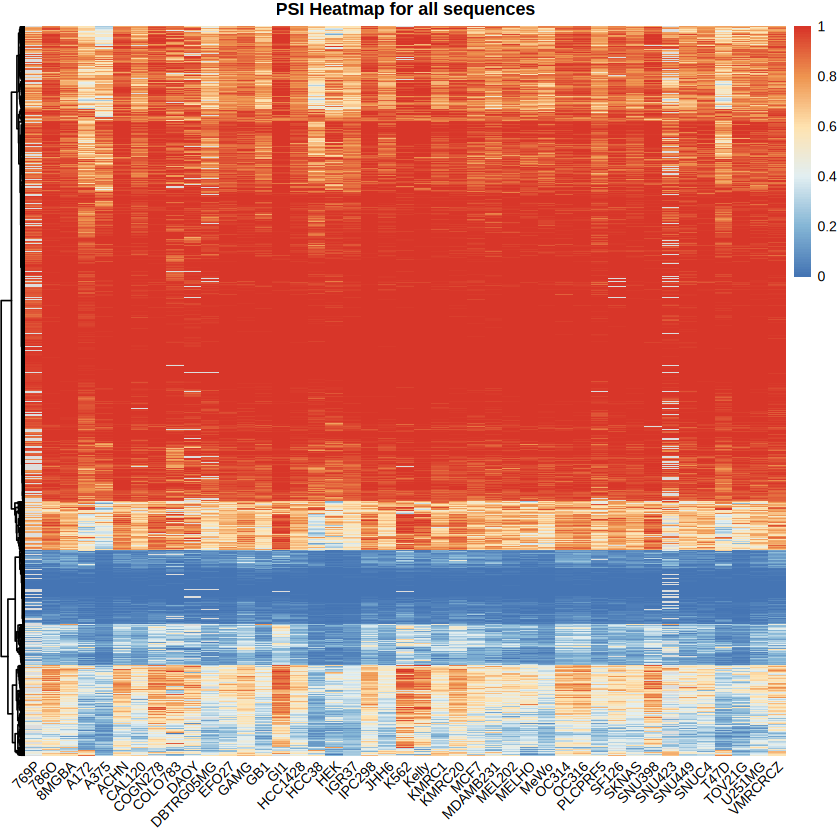

In [8]:
psi_table_pivot_by_condition_mat <- as.matrix(psi_table_pivot %>% select(-index_offset))
rownames(psi_table_pivot_by_condition_mat) <- psi_table_pivot$index_offset
# Filter out rows with >10% NAs.
psi_table_pivot_by_condition_mat <- psi_table_pivot_by_condition_mat[rowMeans(is.na(psi_table_pivot_by_condition_mat)) < 0.05, ]

# color_palette2 <- c("#4575B4", "#80AED1", "#DFF2F6", "#FFE7B8", "#F08944", "#D83629")
color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)

# Plot the PSI_table_pivot big heatmap by condition.
p1 <- pheatmap(psi_table_pivot_by_condition_mat, 
               color = color_palette2_custom, 
               cluster_rows = T,   # Allow clustering for better visualization
               cluster_cols = F,   # Allow clustering for better visualization
                fontsize = 8,         # Increased font size for readability
                border_color = NA,
         main = "PSI Heatmap for all sequences",
         treeheight_row = 10,  # Reduce tree height for better spacing
         treeheight_col = 10,
         show_rownames = FALSE,
         angle_col = 45)      # Cut the tree to create 2 row clusters
ggsave(filename = paste0(output_filepath, "/V3_PSI_heatmap_all_sequences_overall.pdf"),
       plot = p1,
       width = 24, height = 16, dpi = 300)

In [9]:
# Save a rastered version of the heatmap.
ggsave(filename = paste0(output_filepath, "/V3_PSI_heatmap_all_sequences_overall.png"),
       plot = p1,
       width = 14, height = 8, dpi = 300, device = "png", 
       bg = "white")

# Cell type-specificity metrics

In [10]:
library(ggpointdensity)
# Create publication-quality visualizations of cell specificity metrics
options(repr.plot.width=8, repr.plot.height=6)
# Upsilon distribution plot
p1 <- ggplot(cell_specific_score, aes(x = upsilon)) + 
  geom_histogram(bins = 50, fill = "#80AED1", color = "black", alpha = 0.8) + 
  labs(title = "Distribution of Upsilon Values", 
       x = "Upsilon", 
       y = "Frequency", 
       caption = "Higher values indicate greater cell type specificity") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/V3_upsilon_distribution.pdf"), plot = p1, width = 8, height = 6, dpi = 300)

# Tau distribution plot
p2 <- ggplot(cell_specific_score, aes(x = tau)) + 
  geom_histogram(bins = 50, fill = "#80AED1", color = "black", alpha = 0.8) + 
  labs(title = "Distribution of Tau Values", 
       x = "Tau", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/V3_tau_distribution.pdf"), plot = p2, width = 8, height = 6, dpi = 300)

# Reverse Upsilon distribution plot
p3 <- ggplot(cell_specific_score, aes(x = upsilon_reverse)) + 
  geom_histogram(bins = 50, fill = "#80AED1", color = "black", alpha = 0.8) + 
  labs(title = "Distribution of Reverse Upsilon Values", 
       x = "Reverse Upsilon", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity (reverse scale)") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/V3_upsilon_reverse_distribution.pdf"), plot = p3, width = 8, height = 6, dpi = 300)

# Reverse Tau distribution plot
p4 <- ggplot(cell_specific_score, aes(x = tau_reverse)) + 
  geom_histogram(bins = 50, fill = "#80AED1", color = "black", alpha = 0.8) + 
  labs(title = "Distribution of Reverse Tau Values", 
       x = "Reverse Tau", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity (reverse scale)") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/V3_tau_reverse_distribution.pdf"), plot = p4, width = 8, height = 6, dpi = 300)

# Plot tau to upsilon.
p5 <- ggplot(cell_specific_score, aes(x = tau, y = upsilon)) + 
  geom_point(alpha = 0.5, fill = "#80AED1", color = "#80AED1", size = 2, stroke = 0.2, shape = 21) + 
  labs(title = "Tau vs Upsilon", 
       x = "Tau",  
       y = "Upsilon") + 
  theme_classic(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5),
        legend.position = "none") +
  scale_x_continuous(expand = c(0.02, 0)) +
  scale_y_continuous(expand = c(0.02, 0))
ggsave(filename = paste0(output_filepath, "/V3_tau_upsilon_plot.pdf"), plot = p5, width = 8, height = 6, dpi = 300)


Warning message:
“Removed 105 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 56 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 105 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] "Total number of cell type specific sequences: 1004"


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


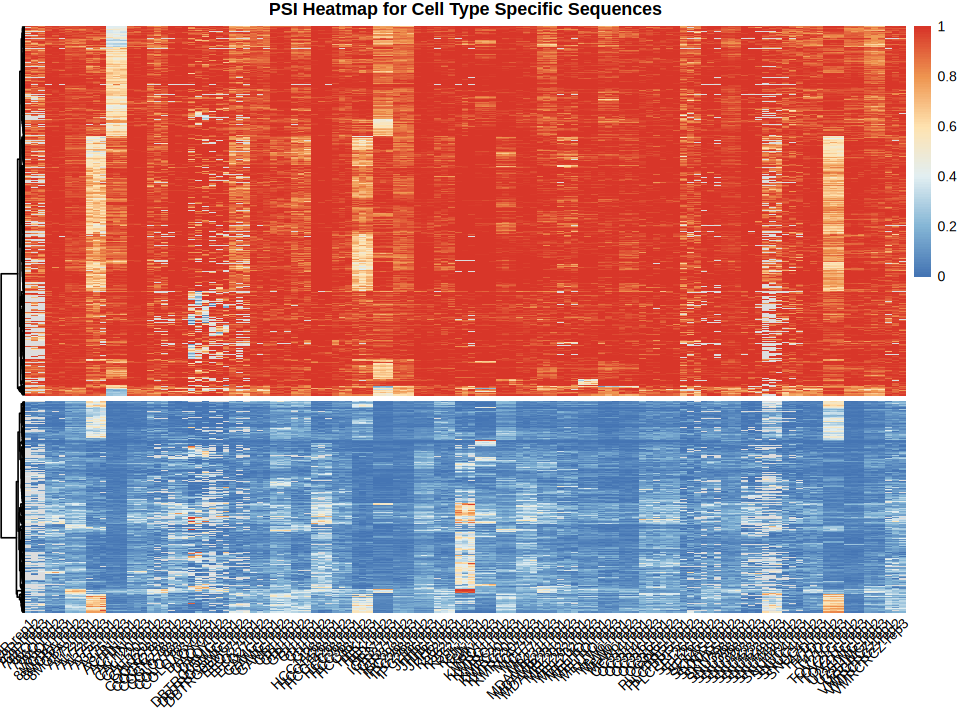

[1] "Processing cell type: 769P with 18 sequences"
[1] "Processing cell type: 786O with 5 sequences"
[1] "Processing cell type: 8MGBA with 6 sequences"
[1] "Processing cell type: A172 with 180 sequences"
[1] "Processing cell type: A375 with 188 sequences"
[1] "Processing cell type: ACHN with 2 sequences"
[1] "Processing cell type: COGN278 with 6 sequences"
[1] "Processing cell type: COLO783 with 121 sequences"
[1] "Processing cell type: DAOY with 28 sequences"
[1] "Processing cell type: DBTRG05MG with 1 sequences"
[1] "Processing cell type: GAMG with 12 sequences"
[1] "Processing cell type: GI1 with 14 sequences"
[1] "Processing cell type: HCC38 with 81 sequences"
[1] "Processing cell type: HEK with 44 sequences"
[1] "Processing cell type: IPC298 with 1 sequences"
[1] "Processing cell type: K562 with 113 sequences"
[1] "Processing cell type: KMRC1 with 4 sequences"
[1] "Processing cell type: KMRC20 with 8 sequences"
[1] "Processing cell type: Kelly with 23 sequences"
[1] "Processing ce

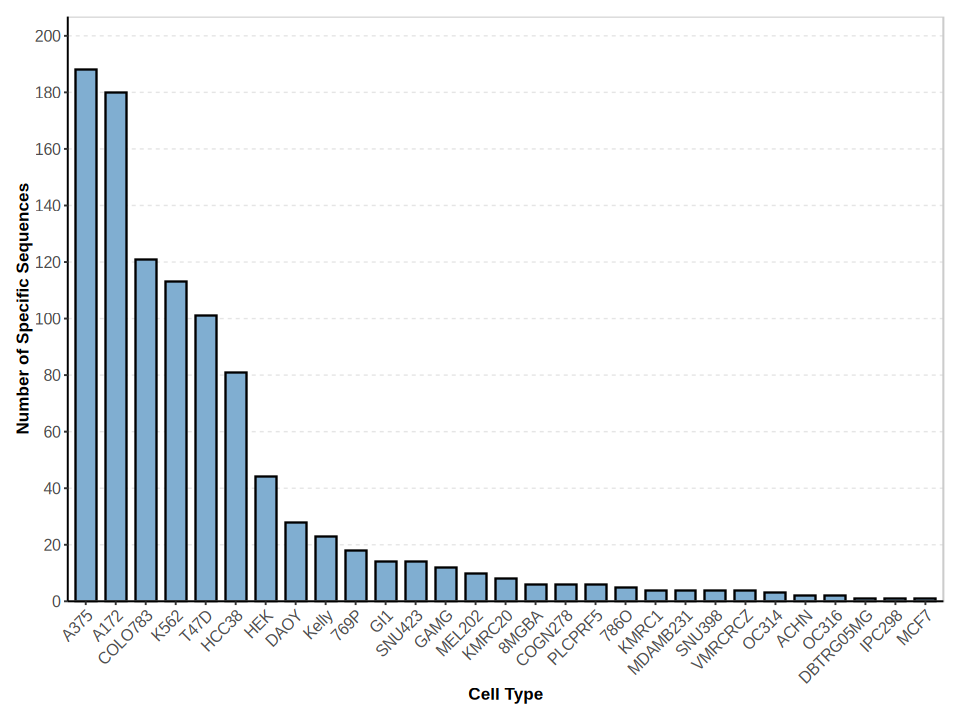

In [ ]:
color_palette1 <- c("#E96052", "#F08944", "#F9AB57", "#FFD16D", "#FFE7B8", "#AADDE1", "#70BDD6", "#4F8DA3", "#336695", "#1A426D")
color_palette1_custom <- colorRampPalette(color_palette1)(100)
color_palette1_custom_rev <- colorRampPalette(rev(color_palette1))(100)

# color_palette2 <- c("#4575B4", "#80AED1", "#DFF2F6", "#FFE7B8", "#F08944", "#D83629")
color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)

# Shortlist to cell type specific sequences.
cell_specific_score_shortlist <- cell_specific_score %>% 
  filter(upsilon >= 0.7 | upsilon_reverse >= 0.7 | 
         (tau >= 0.7 & (row_max - row_min >= 0.3)) | 
         (tau_reverse >= 0.7 & (row_max - row_min >= 0.3))) %>%
  arrange(desc(upsilon))


# shortlist psi_table_mat
psi_table_mat_high_upsilon <- psi_table_mat[rownames(psi_table_mat) %in% cell_specific_score_shortlist$index_offset, ]

p1 <- pheatmap(psi_table_mat_high_upsilon, 
         color = color_palette2_custom, 
         cluster_rows = T,   # Allow clustering for better visualization
         cluster_cols = F,   # Allow clustering for better visualization
         fontsize = 8,         # Increased font size for readability
         border_color = NA,
         main = "PSI Heatmap for Cell Type Specific Sequences",
         treeheight_row = 10,  # Reduce tree height for better spacing
         treeheight_col = 10,
         show_rownames = FALSE,
         angle_col = 45,       # Tilt column labels for readability
         cutree_rows = 2)      # Cut the tree to create 2 row clusters
ggsave(filename = paste0(output_filepath, "/V3_PSI_heatmap_celltype_specific_big.pdf"),
       plot = p1,
       width = 24, height = 16, dpi = 300)

## Get number of cell types in each group
num_cell_type_high_tau <- cell_specific_score_shortlist %>% 
    mutate(target_cell_type = case_when(
      upsilon >= 0.7 | tau >= 0.7 ~ max_sample,
      TRUE ~ min_sample
    )) %>% 
    group_by(target_cell_type) %>%
  summarise(num_cell_type = n()) 

total_index_count <- sum(num_cell_type_high_tau$num_cell_type)
print(paste("Total number of cell type specific sequences:", total_index_count))


num_cell_type_high_tau_to_save <- cell_specific_score_shortlist %>% 
  mutate(target_cell_type = ifelse(upsilon > 0.5, max_sample, min_sample))
write_csv(num_cell_type_high_tau_to_save, 
         file = paste0(output_filepath, "/V3_num_cell_type_celltype_specific.csv"))
# Save the psi_table_mat_high_upsilon
write_csv(as.data.frame(psi_table_mat_high_upsilon), 
         file = paste0(output_filepath, "/V3_psi_table_mat_celltype_specific.csv"))

theme_publication <- theme_classic(base_size = 9) + 
  theme(
    strip.text = element_text(face = "bold", size = 9),  # Bold facet labels
    axis.text = element_text(size = 9),  # Readable axis labels
    axis.title = element_text(size = 9, face = "bold"),  # Emphasized axis titles
    legend.position = "right",  # Show legend
    panel.spacing = unit(0.8, "lines")  # Reduce facet spacing
  )

ggplot(num_cell_type_high_tau, aes(x = reorder(target_cell_type, -num_cell_type), y = num_cell_type)) + 
  geom_bar(stat = "identity", fill = "#80AED1", color = "black", width = 0.7) + 
  labs(x = "Cell Type", y = "Number of Specific Sequences") + 
  theme_publication + 
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.title = element_text(size = 10, face = "bold"),
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10),
    panel.grid.major.y = element_line(color = "grey90", linetype = "dashed", size = 0.3),
    panel.border = element_rect(color = "grey80", fill = NA, size = 0.5)
  ) + 
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1)),
    breaks = scales::pretty_breaks(n = 8)
  )
ggsave(filename = paste0(output_filepath, "/V3_num_cell_type_high_tau.pdf"), 
       width = 10, height = 6, dpi = 300)

# Plot only the sequences high in each cell type.
base_height <- 8
base_rows <- 50

for (i in 1:nrow(num_cell_type_high_tau)) {
  cell_type <- num_cell_type_high_tau$target_cell_type[i]
  num_cell_type <- num_cell_type_high_tau$num_cell_type[i]
  print(paste("Processing cell type:", cell_type, "with", num_cell_type, "sequences"))
  
  # Get the indices of the top num_cell_type sequences for this cell type
  top_indices <- cell_specific_score_shortlist %>% 
    mutate(target_cell_type = case_when(
      upsilon >= 0.7 | tau >= 0.7 ~ max_sample,
      TRUE ~ min_sample
    )) %>% 
    filter(target_cell_type == cell_type) %>% 
    arrange(desc(upsilon)) %>% 
    head(5) %>% 
    # head(num_cell_type) %>% 
    pull(index_offset)

  psi_sub <- psi_table_mat_high_upsilon[top_indices, ]

  # If only one row, add a dummy NA row to avoid pheatmap error
  if (is.null(dim(psi_sub))) {
    psi_sub <- rbind(psi_sub, NA)
    rownames(psi_sub)[2] <- "DUMMY_NA"
  }

  # Compute dynamic height
  n_rows <- nrow(psi_sub)
  heatmap_height <- max(1.8, base_height * (n_rows / base_rows))  # Set a lower bound of 4 to avoid too small plots

  cluster_rows_value <- ifelse(n_rows > 2, TRUE, FALSE)
  # Create heatmap
  p2 <- pheatmap(
    psi_sub, 
    # color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100), 
    color = color_palette2_custom,
    cluster_rows = cluster_rows_value,
    cluster_cols = FALSE,
    fontsize = 8,
    border_color = NA,
    main = paste("PSI Heatmap for Cell Type Specific Sequences in", cell_type),
    treeheight_row = 10,
    treeheight_col = 10,
    show_rownames = TRUE,
    angle_col = 45,
    silent = TRUE,
    breaks = seq(0, 1, length.out = 101)
  )
  ggsave(
    filename = paste0(output_filepath, "/V3_PSI_heatmap_celltype_specific_", cell_type, ".pdf"),
    plot = p2,
    width = 25,
    height = heatmap_height,
    dpi = 300
  )
}

# Now also look at the RMATS outputs

In [12]:
combined_psi <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/pairadise_indiv_PSI/WT_PSI_combined_output_indiv.tsv")
# combined_psi <- fread("~/Dropbox (Harvard University)/02Splicing/latest/Nova240826_3ss_combined_output_indiv.tsv")
calculate_ratio <- function(I, S) {
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  ratio <- I_values / (I_values + S_values)
  # Check if any of the values are NaN
  if (any(is.nan(ratio))) {
    ratio[is.nan(ratio)] <- NA
  }
  return(paste(round(ratio,3), collapse = ","))
}

calculate_average <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  average <- mean(PSI_values, na.rm = T)
  return(round(average, 3))
}

get_max_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  max_PSI <- max(PSI_values, na.rm = T)
  return(round(max_PSI, 3))
}

get_min_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  min_PSI <- min(PSI_values, na.rm = T)
  return(round(min_PSI, 3))
}

calculate_average_count_sum <- function(I, S){
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  total_sum <- I_values + S_values
  average_count_sum <- mean(total_sum)
  return(round(average_count_sum, 0))
}

# Apply the function to the data frame
combined_psi <- combined_psi %>%
  # Filter out folders that contain the word "A172" or Kelly or T47D
#   filter(!grepl("Kelly", Folder)) %>%
#   filter(!grepl("T47D", Folder)) %>%
#   filter(!grepl("A172", Folder)) %>%
#   filter(!grepl("HCC38", Folder)) %>%
#   filter(!grepl("IPC298", Folder)) %>%
#   filter(!grepl("KMRC20", Folder)) %>%
#   filter(!grepl("KMRC1", Folder)) %>%
#   filter(!grepl("HEK", Folder)) %>%
  mutate(
    PSI1 = mapply(calculate_ratio, I1, S1),
    PSI2 = mapply(calculate_ratio, I2, S2)
  ) %>% 
  mutate(
    PSI1_average = mapply(calculate_average, PSI1),
    PSI2_average = mapply(calculate_average, PSI2)
  ) %>%
  mutate(PSI_diff = PSI1_average - PSI2_average) %>% 
  mutate(
    count_sum_average1 = mapply(calculate_average_count_sum, I1, S1),
    count_sum_average2 = mapply(calculate_average_count_sum, I2, S2)
  ) %>% mutate(PSI_ratio = PSI1_average / PSI2_average) %>% 
  mutate(PSI_reverse_ratio = (1-PSI1_average)/(1-PSI2_average)) %>% 
  mutate(max_PSI1 = mapply(get_max_PSI, PSI1), max_PSI2 = mapply(get_max_PSI, PSI2)) %>% 
  mutate(min_PSI1 = mapply(get_min_PSI, PSI1), min_PSI2 = mapply(get_min_PSI, PSI2))


combined_psi_filtered <- combined_psi %>% 
  filter(count_sum_average1 >= 30) %>% 
  filter(count_sum_average2 >= 30) %>% 
  mutate(log2_PSI_ratio = log2(PSI_ratio), log2_PSI_reverse_ratio = log2(PSI_reverse_ratio))

In [13]:
# head(combined_psi_filtered)
# num_cell_type_high_tau_to_save
# Create publication-quality volcano plot
p4 <- ggplot(combined_psi_filtered, aes(x = log2_PSI_ratio, y = -log10(FDR))) + 
  geom_point(aes(color = abs(log2_PSI_ratio) > 1 & -log10(FDR) > 2), 
             size = 0.8, alpha = 0.8) +
  scale_color_manual(values = c("TRUE" = "#E41A1C", "FALSE" = "#377EB8")) +
  geom_hline(yintercept = 2, linetype = "dashed", color = "darkgray") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "darkgray") +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    strip.background = element_rect(fill = "white", color = "black"),
    strip.text = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid.major = element_line(color = "gray90", linewidth = 0.2),
    panel.border = element_rect(color = "black", fill = NA)
  ) +
  facet_wrap(~Folder) +
  labs(
    x = expression(log[2]~"(PSI Ratio)"),
    y = expression(-log[10]~"(FDR)"),
    title = "Differential PSI Analysis"
  )

# Save high-resolution figure
ggsave(filename = paste0(output_filepath, "/WT_log2_PSI_ratio_FDR.pdf"), 
       plot = p4, width = 12, height = 10, dpi = 300)

Warning message:
“Removed 17 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 603 rows containing non-finite outside the scale range (`stat_bin()`).”


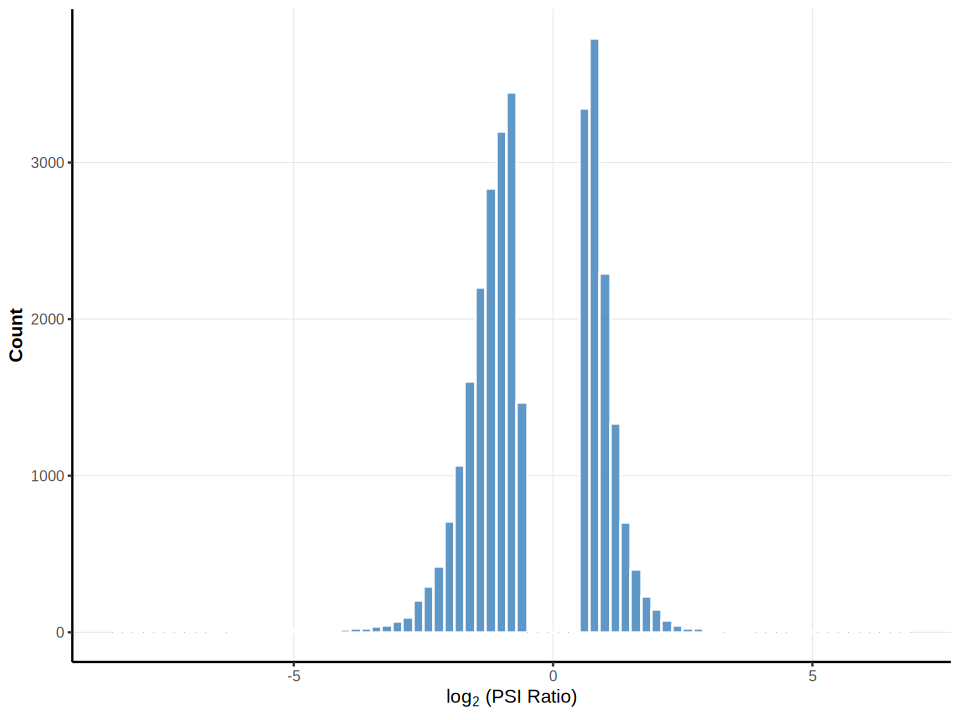

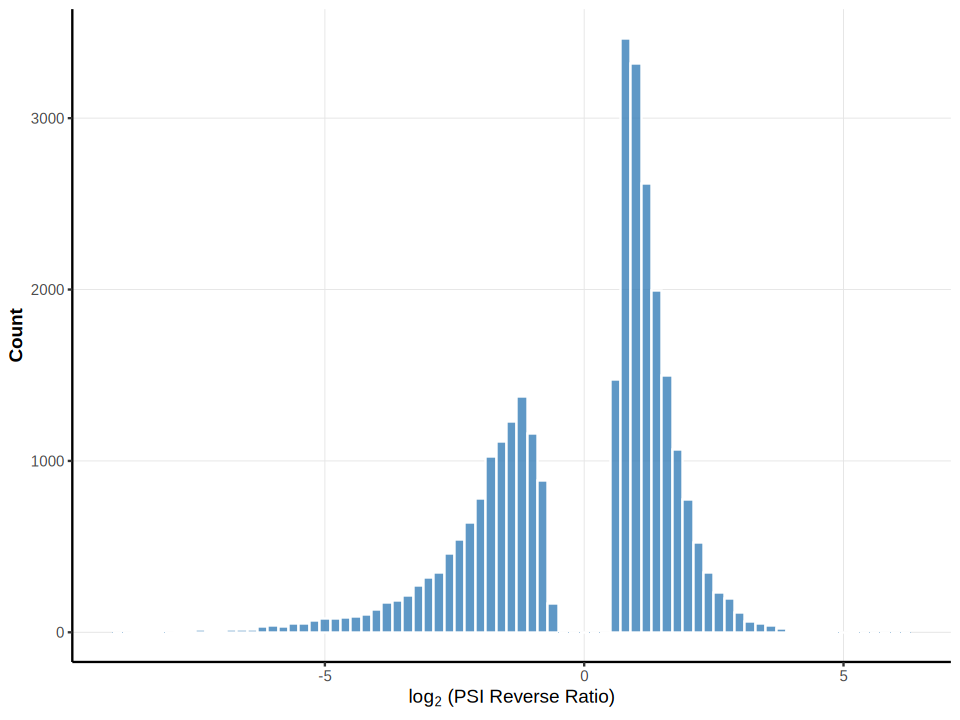

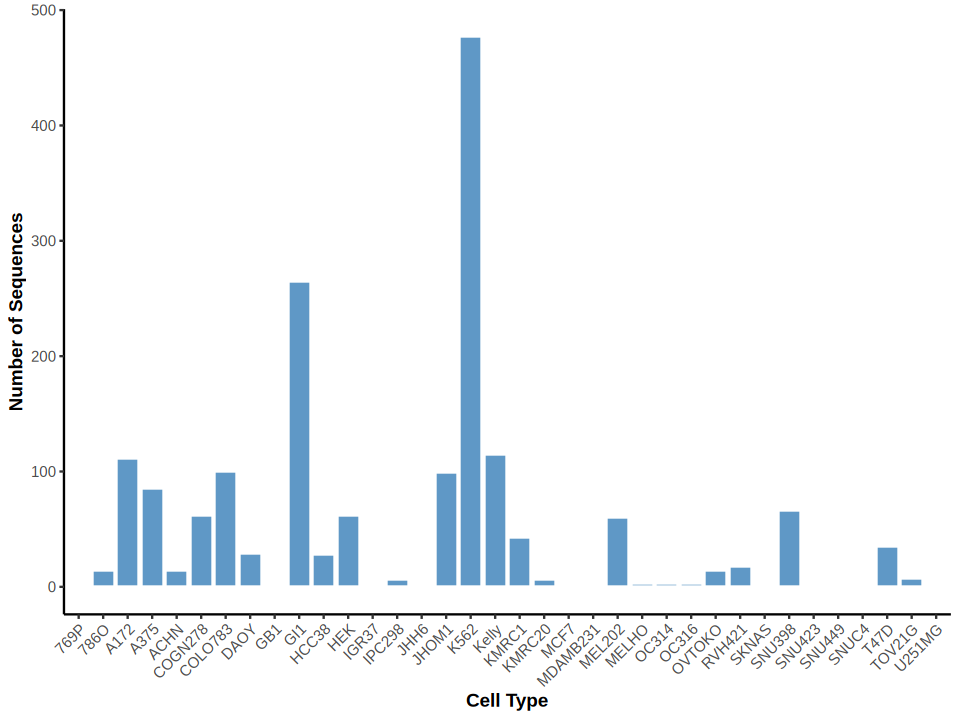

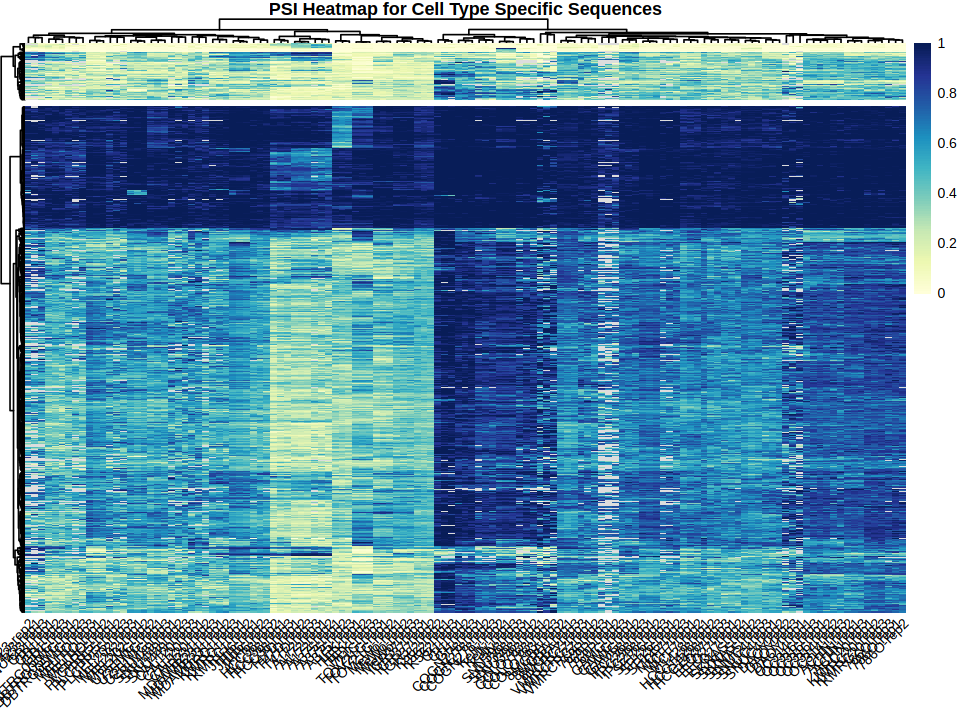

In [14]:
combined_psi_filtered_shortlist <- combined_psi_filtered %>% 
    filter(abs(PSI_diff) >= 0.3) %>% 
    filter(abs(log2_PSI_ratio) >= 3 | abs(log2_PSI_reverse_ratio) >= 3) %>% 
    # Mutate the folder so to strip the WT_ and _all part.
    mutate(Folder = gsub("WT_", "", Folder)) %>% 
    mutate(Folder = gsub("_all", "", Folder)) %>% 
    # remove K562all and K562K700E
    filter(Folder != "K562all") %>% 
    filter(Folder != "K562K700E")

ggplot(combined_psi_filtered %>% filter(abs(PSI_diff) >= 0.3), aes(x = log2_PSI_ratio)) + 
  geom_histogram(binwidth = 0.2, fill = "#377EB8", color = "white", alpha = 0.8) +
  theme_classic() +
  labs(x = expression(log[2]~"(PSI Ratio)"), y = "Count") +
  theme(
    axis.title = element_text(face = "bold"),
    panel.grid.major = element_line(color = "gray90", linewidth = 0.2)
  )

ggplot(combined_psi_filtered %>% filter(abs(PSI_diff) >= 0.3), aes(x = log2_PSI_reverse_ratio)) + 
  geom_histogram(binwidth = 0.2, fill = "#377EB8", color = "white", alpha = 0.8) +
  theme_classic() +
  labs(x = expression(log[2]~"(PSI Reverse Ratio)"), y = "Count") +
  theme(
    axis.title = element_text(face = "bold"),
    panel.grid.major = element_line(color = "gray90", linewidth = 0.2)
  )

num_seq_per_cell_type <- combined_psi_filtered_shortlist %>% 
  filter(abs(PSI_diff) >= 0.3) %>% 
  group_by(Folder) %>% 
  summarise(num_seq = n())


# plot num_seq_per_cell_type
ggplot(num_seq_per_cell_type, aes(x = Folder, y = num_seq)) + 
  geom_bar(stat = "identity", fill = "#377EB8", color = "white", alpha = 0.8) +
  theme_classic() +
  labs(x = "Cell Type", y = "Number of Sequences") +
  theme(axis.title = element_text(face = "bold")) + 
  # rotate x axis labels
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))


psi_table_mat_high_upsilon <- psi_table_mat[rownames(psi_table_mat) %in% unique(combined_psi_filtered_shortlist$ExonID), ]

p1 <- pheatmap(psi_table_mat_high_upsilon, 
         color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100), 
         cluster_rows = T,   # Allow clustering for better visualization
         cluster_cols = T,   # Allow clustering for better visualization
         fontsize = 8,         # Increased font size for readability
         border_color = NA,
         main = "PSI Heatmap for Cell Type Specific Sequences",
         treeheight_row = 10,  # Reduce tree height for better spacing
         treeheight_col = 10,
         show_rownames = FALSE,
         angle_col = 45,       # Tilt column labels for readability
         cutree_rows = 2)      # Cut the tree to create 2 row clusters
ggsave(filename = paste0(output_filepath, "/PSI_heatmap_celltype_specific_rmats_big.pdf"),
       plot = p1,
       width = 24, height = 16, dpi = 300)

# Look at grouping by transcriptomic group

In [15]:
############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 5) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}

# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 5) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}
########################################################

transcriptome_groups <- read_csv("/mnt/dawnccle2/melange/data/cellline_data_with_cluster.csv") %>% 
select(display_name, cluster)

psi_by_condition_with_transcriptome_group <- psi_by_condition %>%
    mutate(condition = toupper(condition)) %>% 
    left_join(transcriptome_groups, by = c("condition" = "display_name")) %>%
    filter(!is.na(cluster)) %>% 
    # Filter out cluster is 18.
    filter(cluster != 18)

psi_table_pivot <- psi_by_condition_with_transcriptome_group %>%
  select(cluster, index_offset, PSI) %>%
  group_by(cluster, index_offset) %>% 
  summarise(PSI = mean(PSI, na.rm = TRUE)) %>% 
  pivot_wider(names_from = c(cluster), values_from = PSI)

psi_table_pivot_sample <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Convert to matrix.
psi_table_mat <- as.matrix(psi_table_pivot_sample %>% select(-index_offset))
rownames(psi_table_mat) <- psi_table_pivot_sample$index_offset

# Calculate upsilon for each row. 
upsilon_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon")

# Calculate reverse upsilon which is 1-values. 
psi_table_pivot_reverse <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  mutate_all(~ 1 - .)  

# Calculate upsilon for each row.
upsilon_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_upsilon) %>% 
  as.data.frame() %>% 
  setNames("upsilon_reverse")


# Calculate tau for each row.
tau_values <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau")

# Calculate reverse tau which is 1-values.
tau_values_reverse <- psi_table_pivot_reverse %>% 
  apply(1, calculate_tau) %>% 
  as.data.frame() %>% 
  setNames("tau_reverse")

# Get num NA per row. 
num_na_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) sum(is.na(x))) %>% 
  as.data.frame() %>% 
  setNames("num_na")

# Get min of each row.
min_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) min(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("min")

# Get max of each row.
max_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) max(x, na.rm = TRUE)) %>% 
  as.data.frame() %>% 
  setNames("max")

# Get the sample where the PSI is max.
max_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.max(x))) %>% 
  as.data.frame() %>% 
  setNames("max_sample")

# Get the sample where the PSI is min.
min_sample_per_row <- psi_table_pivot %>% 
  select(-index_offset) %>% 
  apply(1, function(x) names(which.min(x))) %>% 
  as.data.frame() %>% 
  setNames("min_sample")

cell_specific_score <- data.frame(index_offset = psi_table_pivot$index_offset, 
                                  upsilon = upsilon_values$upsilon, 
                                  upsilon_reverse = upsilon_values_reverse$upsilon_reverse,
                                  tau = tau_values$tau,
                                  tau_reverse = tau_values_reverse$tau_reverse,
                                  num_na_per_row = num_na_per_row$num_na,
                                  row_max = max_per_row$max,
                                  row_min = min_per_row$min,
                                  max_sample = max_sample_per_row$max_sample,
                                  min_sample = min_sample_per_row$min_sample) %>%
  filter(num_na_per_row < 5)

# Upsilon distribution plot
p1 <- ggplot(cell_specific_score, aes(x = upsilon)) + 
  geom_histogram(bins = 50, fill = "#3182bd", color = "#08519c", alpha = 0.8) + 
  labs(title = "Distribution of Upsilon Values", 
       x = "Upsilon", 
       y = "Frequency", 
       caption = "Higher values indicate greater cell type specificity") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/", "transcriptomic_group_upsilon_distribution.pdf"), plot = p1, width = 8, height = 6, dpi = 300)

# Tau distribution plot
p2 <- ggplot(cell_specific_score, aes(x = tau)) + 
  geom_histogram(bins = 50, fill = "#3182bd", color = "#08519c", alpha = 0.8) + 
  labs(title = "Distribution of Tau Values", 
       x = "Tau", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/", "transcriptomic_group_tau_distribution.pdf"), plot = p2, width = 8, height = 6, dpi = 300)

# Reverse Upsilon distribution plot
p3 <- ggplot(cell_specific_score, aes(x = upsilon_reverse)) + 
  geom_histogram(bins = 50, fill = "#3182bd", color = "#08519c", alpha = 0.8) + 
  labs(title = "Distribution of Reverse Upsilon Values", 
       x = "Reverse Upsilon", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity (reverse scale)") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/", "transcriptomic_group_upsilon_reverse_distribution.pdf"), plot = p3, width = 8, height = 6, dpi = 300)

# Reverse Tau distribution plot
p4 <- ggplot(cell_specific_score, aes(x = tau_reverse)) + 
  geom_histogram(bins = 50, fill = "#3182bd", color = "#08519c", alpha = 0.8) + 
  labs(title = "Distribution of Reverse Tau Values", 
       x = "Reverse Tau", 
       y = "Frequency",
       caption = "Higher values indicate greater cell type specificity (reverse scale)") + 
  theme_minimal(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))
ggsave(filename = paste0(output_filepath, "/", "transcriptomic_group_tau_reverse_distribution.pdf"), plot = p4, width = 8, height = 6, dpi = 300)

# Plot tau to upsilon.
p5 <- ggplot(cell_specific_score, aes(x = tau, y = upsilon)) + 
  geom_point(alpha = 0.5, fill = "#3182bd", color = "#3182bd", size = 2, stroke = 0.2, shape = 21) + 
  labs(title = "Tau vs Upsilon", 
       x = "Tau",  
       y = "Upsilon") + 
  theme_classic(base_size = 14) + 
  theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(color = "black"),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5),
        legend.position = "none") +
  scale_x_continuous(expand = c(0.02, 0)) +
  scale_y_continuous(expand = c(0.02, 0))
ggsave(filename = paste0(output_filepath, "/", "transcriptomic_group_tau_upsilon_plot.pdf"), plot = p5, width = 8, height = 6, dpi = 300)


Rows: 73 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): sampleID, display_name, lineage, subtype, func_lineage, Primary/Me...
dbl  (3): cluster, growth_rate, num_in_cluster

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'cluster'. You can override using the
`.groups` argument.
Warning message:
“Removed 270 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 80 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 270 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] "Total number of cell type specific sequences: 46"


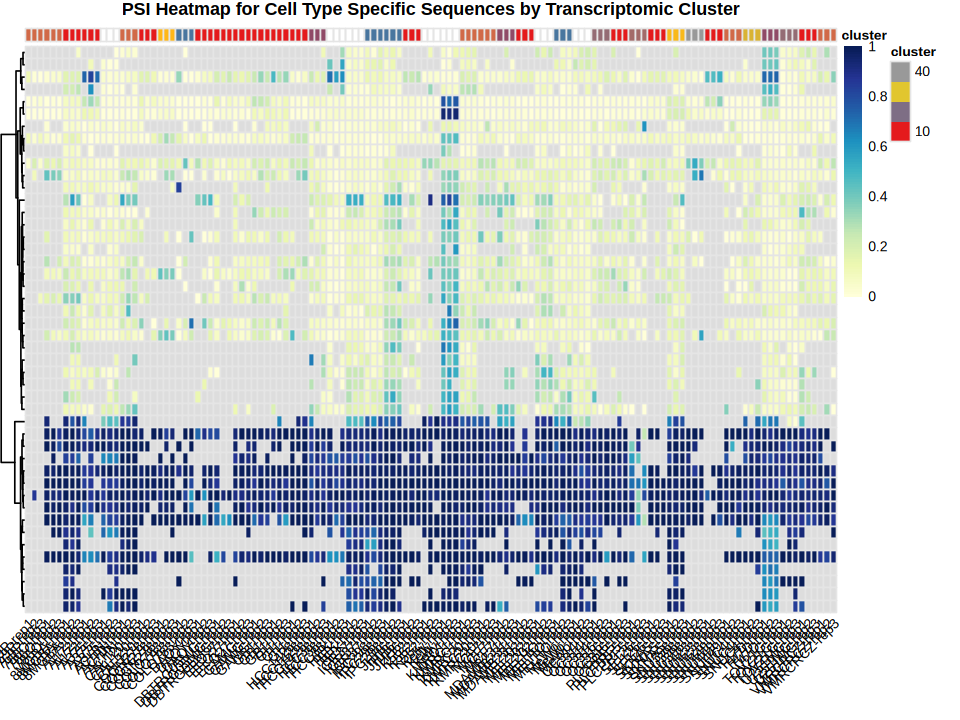

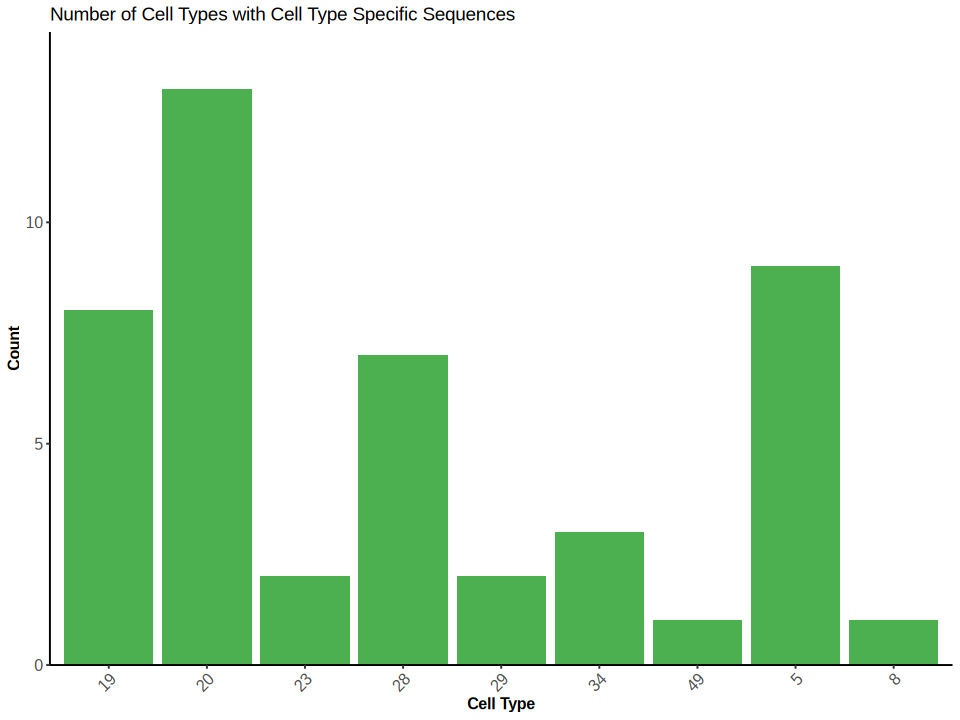

In [16]:
# Shortlist to cell type specific sequences. The metric is as follows:
# Either upsilon > 0.6 or upsilon_reverse > 0.6. 
# Or (tau > 0.6 and max-min > 0.2) or (tau_reverse > 0.6 and max-min > 0.2). 

cell_specific_score_shortlist <- cell_specific_score %>% 
  filter(upsilon >= 0.7 | upsilon_reverse >= 0.7 | 
         (tau >= 0.7 & (row_max - row_min >= 0.3)) | 
         (tau_reverse >= 0.85 & (row_max - row_min >= 0.3))) %>%
  arrange(desc(upsilon))


# shortlist psi_table_mat
psi_table_mat_high_upsilon <- psi_table_mat[rownames(psi_table_mat) %in% cell_specific_score_shortlist$index_offset, ]

# Extract condition names from column names (removing the -repX part)
col_conditions <- gsub("-rep\\d+$", "", colnames(psi_table_mat_high_upsilon))

# Get cluster information for each cell line
condition_cluster_mapping <- psi_by_condition_with_transcriptome_group %>% 
    select(condition, cluster) %>% 
    distinct()

# Create annotation for columns based on transcriptomic cluster
col_annotation <- data.frame(
  cluster = condition_cluster_mapping$cluster[match(col_conditions, condition_cluster_mapping$condition)]
)
rownames(col_annotation) <- colnames(psi_table_mat_high_upsilon)

# Define colors for clusters
library(RColorBrewer)
n_clusters <- length(unique(na.omit(col_annotation$cluster)))
# There are 10 clusters but Set1 palette has a maximum of 9 colors
# Use colorRampPalette to extend the Set1 palette to 10 colors
cluster_colors <- colorRampPalette(brewer.pal(9, "Set1"))(10)
names(cluster_colors) <- sort(unique(na.omit(col_annotation$cluster)))
annotation_colors <- list(cluster = cluster_colors)

# Heatmap
library(pheatmap)

p1 <- pheatmap(psi_table_mat_high_upsilon, 
         color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100), 
         cluster_rows = TRUE,   # Allow clustering for better visualization
         cluster_cols = FALSE,   # Allow clustering for better visualization
         annotation_col = col_annotation,  # Add cluster annotation
         annotation_colors = annotation_colors,  # Add colors for clusters
         fontsize = 8,         # Increased font size for readability
         border_color = "grey90", # Subtle grid lines
         main = "PSI Heatmap for Cell Type Specific Sequences by Transcriptomic Cluster",
         treeheight_row = 10,  # Reduce tree height for better spacing
         treeheight_col = 10,
         show_rownames = FALSE,
         angle_col = 45)       # Tilt column labels for readability
ggsave(filename = paste0(output_filepath, "/PSI_heatmap_celltype_specific_transcriptome_group.pdf"),
       plot = p1,
       width = 24, height = 16, dpi = 300)
# ggsave(filename = paste0(output_filepath, "/PSI_heatmap_high_upsilon.pdf"), 
#        plot = p1,  
#        width = 12, height = 8, dpi = 300)

## Get number of cell types in each group
num_cell_type_high_tau <- cell_specific_score_shortlist %>% 
  mutate(target_cell_type = ifelse(upsilon > 0.5, max_sample, min_sample)) %>% 
  group_by(target_cell_type) %>%
  summarise(num_cell_type = n()) 

total_index_count <- sum(num_cell_type_high_tau$num_cell_type)
print(paste("Total number of cell type specific sequences:", total_index_count))


num_cell_type_high_tau_to_save <- cell_specific_score_shortlist %>% 
  mutate(target_cell_type = ifelse(upsilon > 0.5, max_sample, min_sample))
write_csv(num_cell_type_high_tau_to_save, 
         file = paste0(output_filepath, "/num_cell_type_celltype_specific_transcriptome_group.csv"))
# Save the psi_table_mat_high_upsilon
write_csv(as.data.frame(psi_table_mat_high_upsilon), 
         file = paste0(output_filepath, "/psi_table_mat_celltype_specific_transcriptome_group.csv"))

theme_publication <- theme_classic(base_size = 9) + 
  theme(
    strip.text = element_text(face = "bold", size = 9),  # Bold facet labels
    axis.text = element_text(size = 9),  # Readable axis labels
    axis.title = element_text(size = 9, face = "bold"),  # Emphasized axis titles
    legend.position = "right",  # Show legend
    panel.spacing = unit(0.8, "lines")  # Reduce facet spacing
  )

ggplot(num_cell_type_high_tau, aes(x = target_cell_type, y = num_cell_type)) + 
  geom_bar(stat = "identity", fill = "#4CAF50") + 
  labs(title = "Number of Cell Types with Cell Type Specific Sequences", x = "Cell Type", y = "Count") + 
  theme_publication + 
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) # Add some space at the top
ggsave(filename = paste0(output_filepath, "/num_cell_type_celltype_specific_transcriptome_group.pdf"), 
       width = 12, height = 8, dpi = 300)


[1] "Processing cell type: 19 with 8 sequences"
[1] "Processing cell type: 20 with 13 sequences"
[1] "Processing cell type: 23 with 2 sequences"


Warning message:
“No sequences found for cell type: 23”


[1] "Processing cell type: 28 with 7 sequences"
[1] "Processing cell type: 29 with 2 sequences"


Warning message:
“No sequences found for cell type: 29”


[1] "Processing cell type: 34 with 3 sequences"


Warning message:
“No sequences found for cell type: 34”


[1] "Processing cell type: 49 with 1 sequences"
[1] "Processing cell type: 5 with 9 sequences"
[1] "Processing cell type: 8 with 1 sequences"


Warning message:
“No sequences found for cell type: 8”


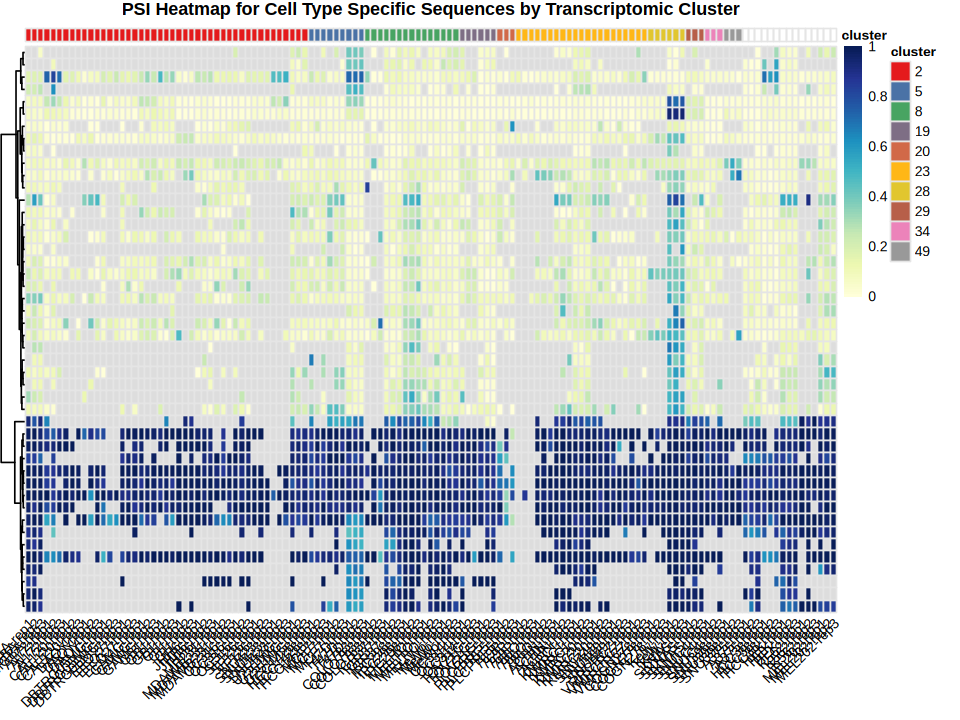

In [17]:
# Shortlist to cell type specific sequences. The metric is as follows:
# Either upsilon > 0.6 or upsilon_reverse > 0.6. 
# Or (tau > 0.6 and max-min > 0.2) or (tau_reverse > 0.6 and max-min > 0.2). 

cell_specific_score_shortlist <- cell_specific_score %>% 
  filter(upsilon >= 0.7 | upsilon_reverse >= 0.7 | 
         (tau >= 0.7 & (row_max - row_min >= 0.3)) | 
         (tau_reverse >= 0.85 & (row_max - row_min >= 0.3))) %>%
  arrange(desc(upsilon))


# shortlist psi_table_mat
psi_table_mat_high_upsilon <- psi_table_mat[rownames(psi_table_mat) %in% cell_specific_score_shortlist$index_offset, ]

# Extract condition names from column names (removing the -repX part)
col_conditions <- gsub("-rep\\d+$", "", colnames(psi_table_mat_high_upsilon)) %>% toupper()

# Get cluster information for each condition
condition_cluster_mapping <- psi_by_condition_with_transcriptome_group %>% 
  select(condition, cluster) %>% 
  distinct()

# Create annotation for columns based on transcriptomic cluster
col_annotation <- data.frame(
  cluster = condition_cluster_mapping$cluster[match(col_conditions, condition_cluster_mapping$condition)]
)
rownames(col_annotation) <- colnames(psi_table_mat_high_upsilon)

# Reorder columns by cluster number
ordered_columns <- colnames(psi_table_mat_high_upsilon)[order(col_annotation$cluster, na.last = TRUE)]
psi_table_mat_high_upsilon <- psi_table_mat_high_upsilon[, ordered_columns]
col_annotation <- col_annotation[ordered_columns, , drop = FALSE]

# Define colors for clusters
library(RColorBrewer)
n_clusters <- length(unique(na.omit(col_annotation$cluster)))
# Convert cluster column to factor (sorted numerically)
col_annotation$cluster <- factor(col_annotation$cluster, levels = sort(unique(na.omit(condition_cluster_mapping$cluster))))

# Define colors for clusters using Set1 and extend if needed
library(RColorBrewer)
n_clusters <- length(levels(col_annotation$cluster))
cluster_palette <- colorRampPalette(brewer.pal(9, "Set1"))(n_clusters)
names(cluster_palette) <- levels(col_annotation$cluster)

# Set annotation color list
annotation_colors <- list(cluster = cluster_palette)

# Draw heatmap
library(pheatmap)
p1 <- pheatmap(
  psi_table_mat_high_upsilon, 
  color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100), 
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = col_annotation,
  annotation_colors = annotation_colors,
  fontsize = 8,
  border_color = "grey90",
  main = "PSI Heatmap for Cell Type Specific Sequences by Transcriptomic Cluster",
  treeheight_row = 10,
  treeheight_col = 10,
  show_rownames = FALSE,
  angle_col = 45
)

# Save heatmap
ggsave(
  filename = paste0(output_filepath, "/PSI_heatmap_celltype_specific_transcriptome_group.pdf"),
  plot = p1,
  width = 24,
  height = 16,
  dpi = 300
)


# Plot only the sequences high in each cell type.
base_height <- 8
base_rows <- 50

for (i in 1:nrow(num_cell_type_high_tau)) {
  cell_type <- num_cell_type_high_tau$target_cell_type[i]
  num_cell_type <- num_cell_type_high_tau$num_cell_type[i]
  print(paste("Processing cell type:", cell_type, "with", num_cell_type, "sequences"))
  
  # Get the indices of the top num_cell_type sequences for this cell type
  top_indices <- cell_specific_score_shortlist %>% 
    mutate(target_cell_type = case_when(
      upsilon >= 0.7 | tau >= 0.7 ~ max_sample,
      TRUE ~ min_sample
    )) %>% 
    filter(target_cell_type == cell_type) %>% 
    arrange(desc(upsilon)) %>% 
    head(num_cell_type) %>% 
    pull(index_offset)

  # Skip if no sequences found for this cell type
  if (length(top_indices) == 0) {
    warning(paste("No sequences found for cell type:", cell_type))
    next
  }

  psi_sub <- psi_table_mat_high_upsilon[top_indices, , drop = FALSE]

  # Check if the matrix contains any non-NA values
  if (all(is.na(psi_sub))) {
    warning(paste("All values are NA for cell type:", cell_type))
    next
  }

  # If only one row, add a dummy row to avoid pheatmap error
  if (nrow(psi_sub) == 1) {
    dummy_row <- rep(0, ncol(psi_sub))
    psi_sub <- rbind(psi_sub, dummy_row)
    rownames(psi_sub)[2] <- "DUMMY_ROW"
  }

  # Compute dynamic height
  n_rows <- nrow(psi_sub)
  heatmap_height <- max(4, base_height * (n_rows / base_rows))  # Set a lower bound of 4 to avoid too small plots

  cluster_rows_value <- ifelse(n_rows > 2, TRUE, FALSE)
  
  # Try-catch block to handle potential errors in pheatmap
  tryCatch({
    # Create heatmap
    p2 <- pheatmap(
      psi_sub, 
      color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100), 
      cluster_rows = cluster_rows_value,
      cluster_cols = FALSE,
      annotation_col = col_annotation,
      annotation_colors = annotation_colors,
      fontsize = 8,
      border_color = NA,
      main = paste("PSI Heatmap for Cell Type Specific Sequences in", cell_type),
      treeheight_row = 10,
      treeheight_col = 10,
      show_rownames = TRUE,
      angle_col = 45,
      silent = TRUE
    )
    ggsave(
      filename = paste0(output_filepath, "/PSI_heatmap_celltype_specific_transcriptomic_group_", cell_type, ".pdf"),
      plot = p2,
      width = 25,
      height = heatmap_height,
      dpi = 300
    )
  }, error = function(e) {
    warning(paste("Error generating heatmap for cell type:", cell_type, "-", e$message))
  })
}

In [18]:
# This is for individual files.

library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}

# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/figure_outputs"
# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual.csv")


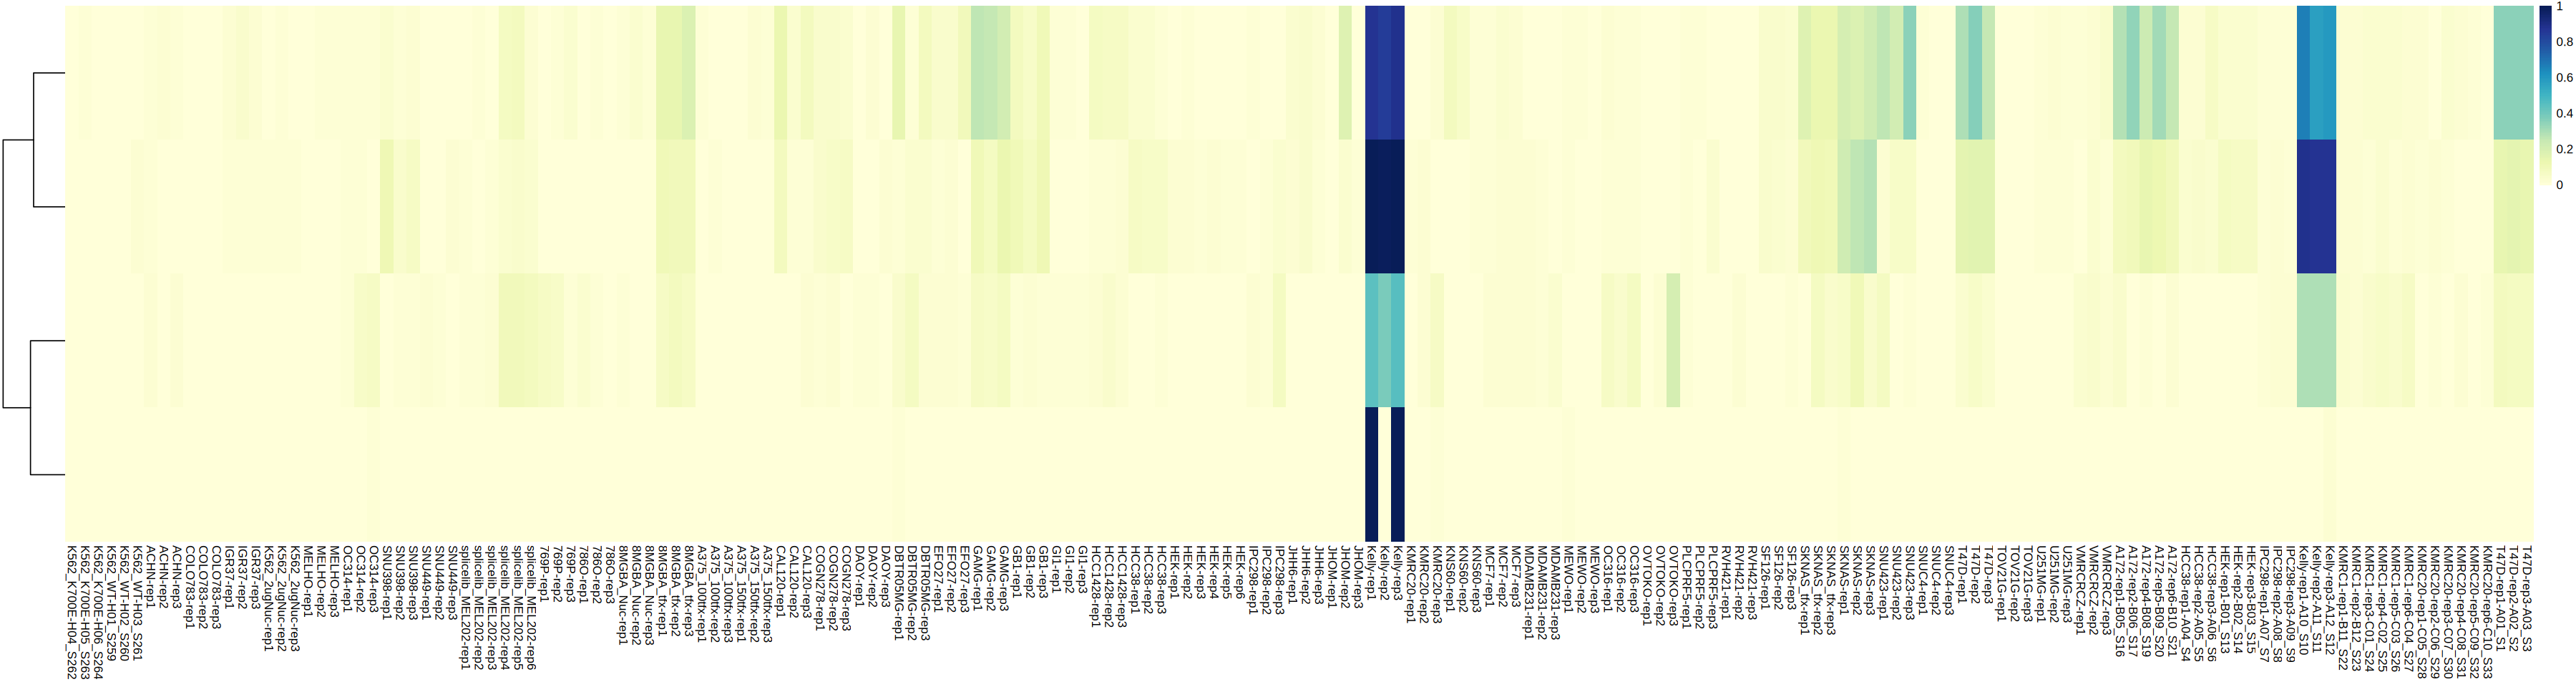

In [19]:
top_index <- c("ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481",
"ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012",
"ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946")

Kelly <- final_psi_table_filtered %>% # filter(condition == "Kelly"| condition == "786O") %>% 
    mutate(PSI = included_count/(included_count + skipped_count)) %>% 
    filter(index %in% top_index) %>% 
    mutate(index_offset = paste0(index, "__", offset)) %>% 
    select(sample, index_offset, PSI) %>% 
    pivot_wider(names_from = sample, values_from = PSI)

# Heatmap of Kelly.
Kelly_heatmap <- Kelly %>% 
  column_to_rownames(var = "index_offset") %>% 
  as.matrix()

# Filter out rows that have > 50% NAs.
Kelly_heatmap <- Kelly_heatmap[rowMeans(is.na(Kelly_heatmap)) < 0.5, ]

# Set figure dimensions to make the heatmap larger
options(repr.plot.width=30, repr.plot.height=8)

pheatmap(Kelly_heatmap, 
         color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100),
         cluster_rows = TRUE, 
         cluster_cols = FALSE,
         show_colnames = TRUE,
         show_rownames = FALSE)
